In [3]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))
print("CUDA version:", torch.version.cuda)

CUDA available: True
Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA version: 11.8


In [5]:
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [6]:
df= pd.read_csv("../../data/imbalanced_data.csv")

In [7]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [8]:
df.shape

(31962, 3)

In [9]:
df.drop("id", axis=1, inplace=True)

<Axes: xlabel='label', ylabel='count'>

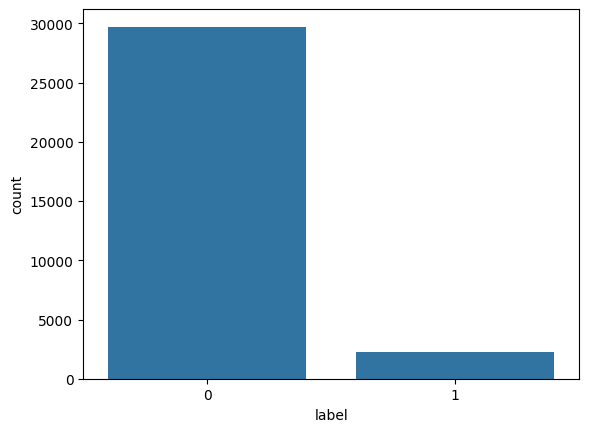

In [10]:
sns.countplot(x="label", data=df)

Since the data is very highly imbalanced so solving this issue by combining the values with other data

In [11]:
df2= pd.read_csv("../../data/raw_data.csv")

In [12]:
df2.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [13]:
df2.columns

Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='str')

The columns like 'Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither' are of no use for balancong of data so just dropping them

In [14]:
df2.drop(columns=['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither'], inplace=True)

In [15]:
df2['class'].unique()

array([2, 1, 0])

<Axes: xlabel='class', ylabel='count'>

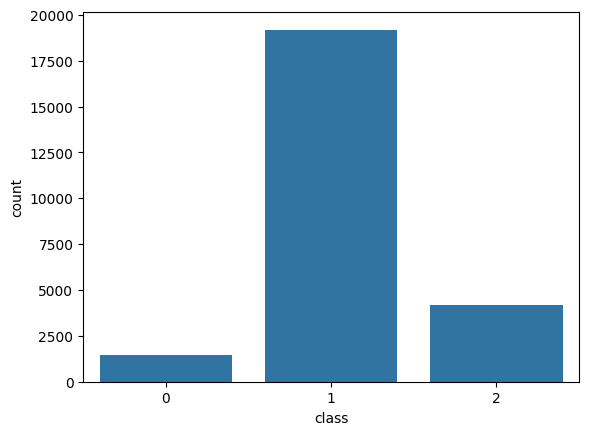

In [16]:
sns.countplot(x="class", data=df2)

0---> hate 1--> abusive 2--> no hate

In [17]:
#copying values of class 0 to class 1   
df2.loc[df2['class'] == 0, 'class'] = 1

In [18]:
df2["class"].replace({0:1},inplace=True)

C:\Users\naman\AppData\Local\Temp\ipykernel_5692\824484888.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df2["class"].replace({0:1},inplace=True)


0        2
1        1
2        1
3        1
4        1
        ..
24778    1
24779    2
24780    1
24781    1
24782    2
Name: class, Length: 24783, dtype: int64

In [19]:
df2['class'].unique()

array([2, 1])

In [20]:
df2.loc[df2['class'] == 2, 'class'] = 0

In [21]:
df2['class'].replace({2:0},inplace=True)

C:\Users\naman\AppData\Local\Temp\ipykernel_5692\1944266385.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df2['class'].replace({2:0},inplace=True)


0        0
1        1
2        1
3        1
4        1
        ..
24778    1
24779    0
24780    1
24781    1
24782    0
Name: class, Length: 24783, dtype: int64

<Axes: xlabel='class', ylabel='count'>

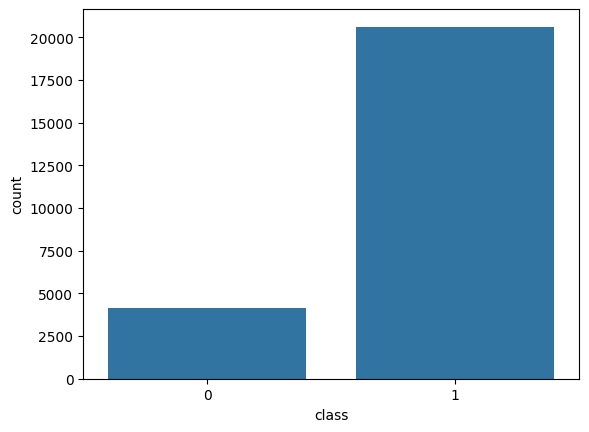

In [22]:
sns.countplot(x="class", data=df2)

In [23]:
df2.rename(columns={'class':'label'}, inplace=True)

In [24]:
df= pd.concat([df, df2], axis=0)

In [25]:
df.shape

(56745, 2)

<Axes: xlabel='label', ylabel='count'>

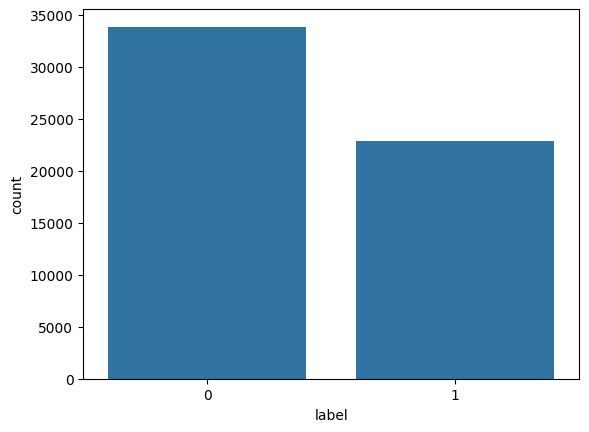

In [26]:
sns.countplot(x="label", data=df)

Now doing preprocessing over text data

In [27]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import string
from warnings import filterwarnings 

In [28]:
stemmer= WordNetLemmatizer()
stopwords = set(stopwords.words('english'))


In [29]:
def data_cleaning(text):
    text = str(text).lower()
    text = re.sub(r'\[<.*?>\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)

    words = text.split()
    words = [word for word in words if word not in stopwords]
    words = [stemmer.lemmatize(word) for word in words]

    return " ".join(words)

In [30]:
df['tweet']=df['tweet'].apply(data_cleaning)

In [31]:
df['tweet']

0        user father dysfunctional selfish drag kid dys...
1        user user thanks lyft credit cant use cause do...
2                                           bihday majesty
3        model love u take u time urð± ðððð...
4                            factsguide society motivation
                               ...                        
24778    yous muthafin lie coreyemanuel right tl trash ...
24779    youve gone broke wrong heart baby drove rednec...
24780    young buck wanna eat dat nigguh like aint fuck...
24781                       youu got wild bitch tellin lie
24782    ruffled ntac eileen dahlia beautiful color com...
Name: tweet, Length: 56745, dtype: str

Now starting with feature engineering

In [32]:
X= df['tweet']
y= df['label']

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

In [35]:
max_words = 50000
max_len = 300

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

sequences = tokenizer.texts_to_sequences(X_train)
sequences_matrix = pad_sequences(sequences,maxlen=max_len)

In [36]:
sequences_matrix

array([[    0,     0,     0, ...,    62,     4,    85],
       [    0,     0,     0, ...,  3125,  1471,  4087],
       [    0,     0,     0, ...,    12, 17729, 17730],
       ...,
       [    0,     0,     0, ...,   516,   103,    72],
       [    0,     0,     0, ...,   871, 14482,   686],
       [    0,     0,     0, ...,   332,   313,     2]],
      shape=(45396, 300), dtype=int32)

In [37]:
from keras.models import Sequential
from keras.layers import LSTM, Activation, Dense, Dropout, Input, Embedding, SpatialDropout1D
from keras.optimizers import RMSprop

In [38]:
model = Sequential()
model.add(Embedding(max_words,100,input_length=max_len))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100,dropout=0.2,recurrent_dropout=0.2))
model.add(Dense(1,activation='sigmoid'))
model.summary()

c:\Users\naman\OneDrive\Desktop\SentinelAi\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics=['accuracy'])

In [40]:
history = model.fit(sequences_matrix, y_train, epochs=5, batch_size=128, validation_split=0.2)

Epoch 1/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 102s 354ms/step - accuracy: 0.8872 - loss: 0.2805 - val_accuracy: 0.9394 - val_loss: 0.1695
Epoch 2/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 115s 406ms/step - accuracy: 0.9466 - loss: 0.1526 - val_accuracy: 0.9443 - val_loss: 0.1602
Epoch 3/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 123s 433ms/step - accuracy: 0.9556 - loss: 0.1302 - val_accuracy: 0.9456 - val_loss: 0.1613
Epoch 4/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 124s 436ms/step - accuracy: 0.9641 - loss: 0.1119 - val_accuracy: 0.9415 - val_loss: 0.1649
Epoch 5/5
284/284 ━━━━━━━━━━━━━━━━━━━━ 128s 452ms/step - accuracy: 0.9686 - loss: 0.1004 - val_accuracy: 0.9426 - val_loss: 0.1680


In [41]:
test_sequences = tokenizer.texts_to_sequences(X_test)
test_sequences_matrix = pad_sequences(test_sequences,maxlen=max_len)

In [42]:
test_sequences_matrix

array([[    0,     0,     0, ...,  3933,     2,  3381],
       [    0,     0,     0, ...,  3201,  2639, 17681],
       [    0,     0,     0, ...,   185,   206,   966],
       ...,
       [    0,     0,     0, ..., 17013,  2701, 42443],
       [    0,     0,     0, ...,   192,   193,   191],
       [    0,     0,     0, ...,   206,    93,  2902]],
      shape=(11349, 300), dtype=int32)

In [43]:
model_eval= model.evaluate(test_sequences_matrix, y_test)

355/355 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9407 - loss: 0.1807


In [44]:
lstm_predict= model.predict(test_sequences_matrix)

355/355 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step


In [45]:
result= []
for predict in lstm_predict:
    if predict > 0.5:
        result.append(1)
    else:
        result.append(0)

In [46]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, result))
print(confusion_matrix(y_test, result))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      6736
           1       0.94      0.91      0.93      4613

    accuracy                           0.94     11349
   macro avg       0.94      0.94      0.94     11349
weighted avg       0.94      0.94      0.94     11349

[[6490  246]
 [ 427 4186]]


In [47]:
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [48]:
model.save('lstm_model.h5')

In [49]:
import keras
load_model=keras.models.load_model("lstm_model.h5")

In [50]:
with open('tokenizer.pickle', 'rb') as handle:
    load_tokenizer = pickle.load(handle)

In [51]:
test = 'Fuck your entire group and everything you stand for, you are nothing but a toxic presence everywhere you go.'
def clean_text(text):
    print(text)
    text = str(text).lower()
    text = re.sub(r'\[<.*?>\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    words = text.split()
    words = [word for word in words if word not in stopwords]
    text=" ".join(words)
    text = [stemmer.lemmatize(word) for word in text.split(' ')]
    text=" ".join(text)
    return text

test=[clean_text(test)]
print(test)

seq = load_tokenizer.texts_to_sequences(test)
padded = pad_sequences(seq, maxlen=300)
print(seq)

pred = load_model.predict(padded)

print("pred", pred)
if pred<0.5:
    print("no hate")
else:
    print("hate and abusive")

Fuck your entire group and everything you stand for, you are nothing but a toxic presence everywhere you go.
['fuck entire group everything stand nothing toxic presence everywhere go']
[[20, 1146, 657, 300, 506, 174, 14728, 5834, 1411, 25]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
pred [[0.10343948]]
no hate


Quite bad results. We need to work on the model and try to improve it.

In [52]:
from datasets import Dataset

train_df = pd.DataFrame({"text": X_train, "label": y_train})
test_df  = pd.DataFrame({"text": X_test,  "label": y_test})

train_dataset = Dataset.from_pandas(train_df)
test_dataset  = Dataset.from_pandas(test_df)

c:\Users\naman\OneDrive\Desktop\SentinelAi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 11349/11349 [00:00<00:00, 31312.00 examples/s]


In [54]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1073.01it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [55]:
import sys
!{sys.executable} -m pip install -U accelerate

In [56]:
import accelerate
print(accelerate.__version__)

1.12.0


In [57]:
pip install transformers[torch]

Note: you may need to restart the kernel to use updated packages.


In [58]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="steps",
    logging_steps=100,
    fp16=True
)

In [59]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.127251,0.150435,0.952947,0.940719,0.964050,0.918491
2,0.133297,0.154278,0.955150,0.944097,0.956812,0.931715


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.79it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=5676, training_loss=0.14323343350233705, metrics={'train_runtime': 1715.9824, 'train_samples_per_second': 52.91, 'train_steps_per_second': 3.308, 'total_flos': 3006745014693888.0, 'train_loss': 0.14323343350233705, 'epoch': 2.0})

In [60]:
trainer.evaluate()

{'eval_loss': 0.15427753329277039,
 'eval_accuracy': 0.955150233500749,
 'eval_f1': 0.9440966501922021,
 'eval_precision': 0.9568121104185218,
 'eval_recall': 0.9317147192716236,
 'eval_runtime': 14.6721,
 'eval_samples_per_second': 773.509,
 'eval_steps_per_second': 48.391,
 'epoch': 2.0}

In [61]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

preds_output = trainer.predict(test_dataset)
preds = np.argmax(preds_output.predictions, axis=1)

print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      6736
           1       0.96      0.93      0.94      4613

    accuracy                           0.96     11349
   macro avg       0.96      0.95      0.95     11349
weighted avg       0.96      0.96      0.96     11349

[[6542  194]
 [ 315 4298]]


In [67]:
def predict_text(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    prediction = torch.argmax(probs).item()

    if prediction == 1:
        print("Hate")
    else:
        print("No Hate")

In [72]:
predict_text("Shut the hell up, you incompetent clown, nobody with half a brain would ever take you seriously.")

Hate


In [73]:
model.save_pretrained("sentinelai_model")
tokenizer.save_pretrained("sentinelai_tokenizer")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.72it/s]


('sentinelai_tokenizer\\tokenizer_config.json',
 'sentinelai_tokenizer\\tokenizer.json')